<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/MachineLearning/SilhoutteClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Silhouette Analysis in Clustering

**Silhouette Analysis** is a comprehensive evaluation technique used to judge the quality of unsupervised clustering models (such as K-Means or Hierarchical Clustering).

While metrics like WCSS (Inertia) only look at how close data points are to their own cluster centers, Silhouette analysis evaluates the **entire topology** of your groups by checking how well-separated the clusters are from each other.

## The Mathematical Breakdown

The silhouette coefficient for a single, individual data point $i$ balances two distinct spatial properties: **Cohesion** ($a$) and **Separation** ($b$).

### 1. Intra-Cluster Distance (Cohesion)
Let $a(i)$ be the mean distance between the data point $i$ and all other data points within the same cluster.

$$\text{Formula: } a(i) = \frac{1}{|A| - 1} \sum_{j \in A, j \neq i} d(i, j)$$

Where:
* $A$ is the cluster to which data point $i$ belongs.
* $|A|$ is the total number of points inside cluster $A$.
* $d(i, j)$ is the distance (usually Euclidean) between point $i$ and point $j$.
* *Goal:* We want $a(i)$ to be as small as possible, indicating a tight, highly cohesive cluster.

### 2. Nearest-Cluster Distance (Separation)
Let $b(i)$ be the mean distance between the data point $i$ and all data points in the **closest neighboring cluster** (the next best cluster that point $i$ could belong to).

$$\text{Formula: } b(i) = \min_{C \neq A} \left( \frac{1}{|C|} \sum_{j \in C} d(i, j) \right)$$

Where:
* $C$ is any neighboring cluster that is *not* cluster $A$.
* $|C|$ is the total number of points inside cluster $C$.
* *Goal:* We want $b(i)$ to be as large as possible, indicating clear separation from neighbors.

### 3. The Final Silhouette Coefficient Formula
Using these two variables, the individual silhouette coefficient $s(i)$ is defined as:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

This can also be written piece-wise to show exactly how it behaves:

$$s(i) = \begin{cases}
1 - \frac{a(i)}{b(i)}, & \text{if } a(i) < b(i) \\
0, & \text{if } a(i) = b(i) \\
\frac{b(i)}{a(i)} - 1, & \text{if } a(i) > b(i)
\end{cases}$$

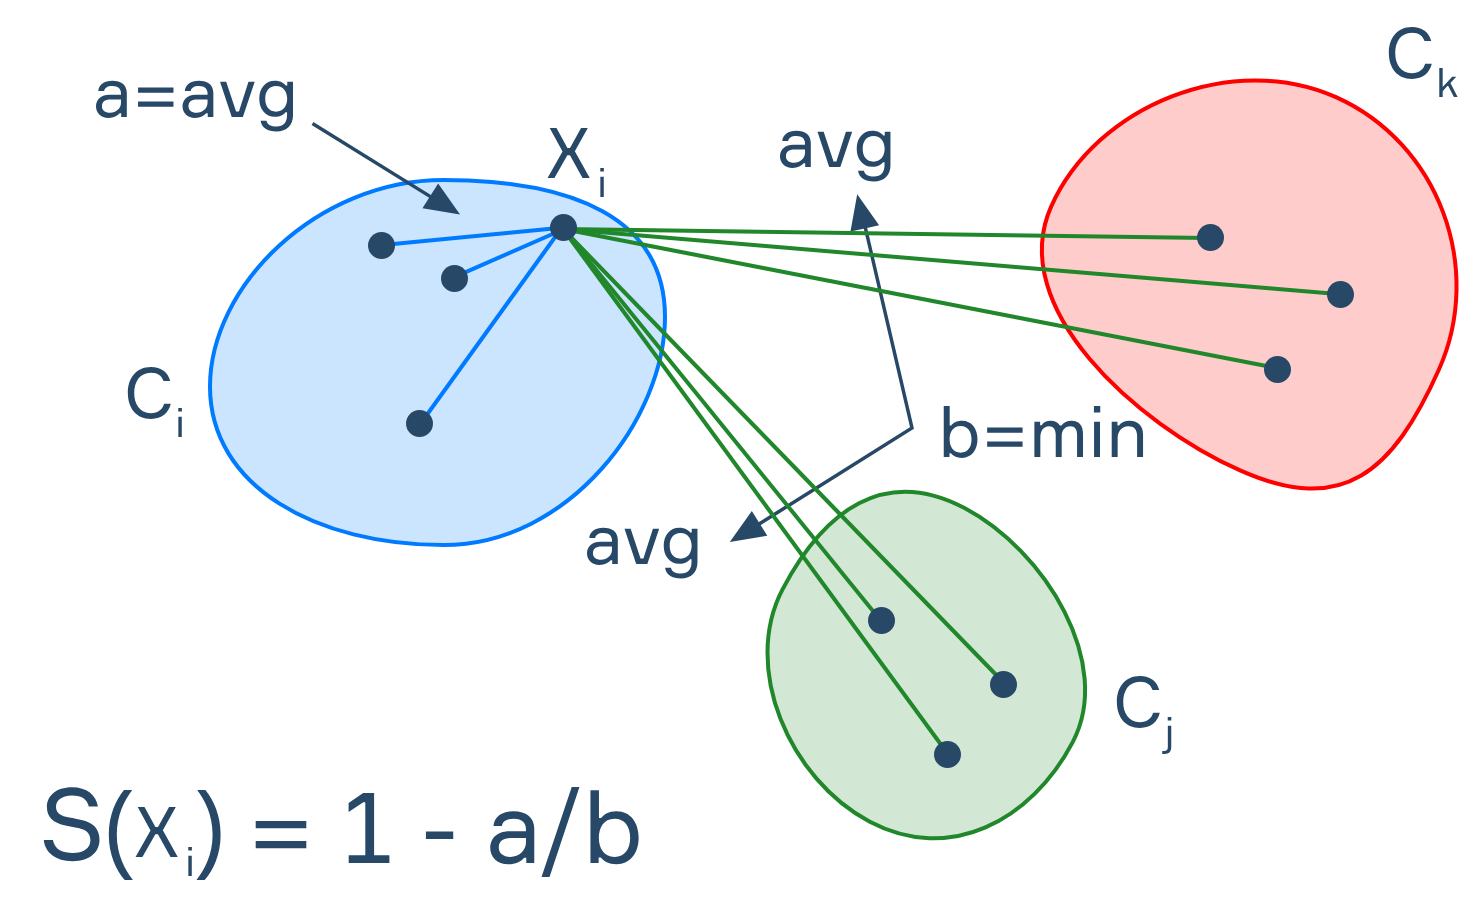

## Interpreting the Score Range

The value of the silhouette coefficient is strictly bounded between **$-1$** and **$+1$**:

* **Score $\approx +1$ (Excellent Clustering):** Indicates that $a(i) \ll b(i)$. The data point is deeply embedded in its assigned cluster and far away from neighboring clusters.
* **Score $\approx 0$ (Overlapping Boundaries):** Indicates that $a(i) \approx b(i)$. The point sits directly on the blurry boundary dividing two separate clusters.
* **Score $\approx -1$ (Wrong Assignment):** Indicates that $a(i) \gg b(i)$. The point is closer to a neighboring cluster than its own, meaning it was likely misclassified.

> **Global Silhouette Score:** The final performance metric for your model is calculated as the average $s(i)$ across **every single data point** in the dataset:
> $$\text{Global Score} = \frac{1}{N}\sum_{i=1}^{N}s(i)$$

## Using Silhouette Plots to Pick the Optimal $K$

Instead of just looking at a single average number, data scientists plot a **Silhouette Diagram**. This chart sorts the silhouette coefficients of all points within each cluster and plots them as horizontal bars.

When inspecting a silhouette plot across different values of $K$, look for these three validation criteria:

1. **Above Average Thickness:** The average global silhouette score is drawn as a vertical dashed line. Every single cluster profile (the "knife shapes") should extend past this dashed line.
2. **Uniform Cluster Size:** The vertical thickness of each cluster block represents the number of points in that cluster. If one block is massive and another is a tiny sliver, the data is unevenly split.
3. **No Negative Dips:** If a cluster contains a long tail extending into negative values (left of 0), it means many data points in that group are hovering in the wrong cluster zone.


## Pros and Cons of Silhouette Clustering Analysis

### Advantages
* **Bounded Scale:** Unlike WCSS, which can range from zero to millions, the silhouette score is always locked between $-1$ and $+1$, making it easy to compare across different models.
* **No Center Bias:** It works well for validating density-based algorithms (like DBSCAN) where clusters don't have a single central centroid point.

### Disadvantages
* **High Computation Cost:** Calculating distances between *every single pair* of points creates a time complexity of $O(N^2)$. It can be slow and memory-intensive on massive datasets.
* **Struggles with Complex Shapes:** It favors convex (spherical) clusters. It might give a low score to perfectly separated crescent moon or ring-shaped clusters simply because their geometric centers are close together.



# ***Impelement Silhoutte Clustering***

# Task
Perform a Silhouette Analysis to determine the optimal number of clusters for a synthetic dataset. This involves generating synthetic data, applying K-Means clustering for a range of 'K' values, calculating and visualizing Silhouette scores, generating Silhouette plots, and finally identifying and summarizing the optimal 'K' based on the analysis.

In [1]:
from sklearn.datasets import make_blobs
import pandas as pd

# Generate synthetic data
X, y = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=1.0, random_state=42)

# Display the first 5 rows of the generated data
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
print("First 5 rows of the generated synthetic data:")
print(df.head())

First 5 rows of the generated synthetic data:
   Feature_1  Feature_2
0  -7.689054   6.620346
1  -9.576514  -6.934404
2   6.829682   1.164871
3  -2.901306   7.550771
4  -5.678413  -7.288185


In [2]:
from sklearn.cluster import KMeans

kmeans_models = []
cluster_labels = []

# Iterate through a range of 'K' values from 2 to 10
for K in range(2, 11):
    # Instantiate KMeans model
    kmeans_model = KMeans(n_clusters=K, random_state=42, n_init='auto')

    # Fit the model to the data
    kmeans_model.fit(X)

    # Append the fitted model and cluster labels to the lists
    kmeans_models.append(kmeans_model)
    cluster_labels.append(kmeans_model.labels_)

K-Means models for K from 2 to 10 have been trained and their labels stored.


## Calculate Silhouette Scores

### Subtask:
For each 'K' value, calculate the average Silhouette score to evaluate the quality of the clustering. Store these scores for comparison.


**Reasoning**:
Import `silhouette_score` and iterate through the `cluster_labels` list to calculate and store the average silhouette score for each K, then print the scores.



In [3]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

# Iterate through the cluster_labels (which corresponds to K=2 to 10)
for i, labels in enumerate(cluster_labels):
    # K starts from 2, so i (index) + 2 gives the current K value
    K = i + 2
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"Silhouette Score for K={K}: {score:.4f}")

print("\nSilhouette scores for each K have been calculated and stored.")

Silhouette Score for K=2: 0.5955
Silhouette Score for K=3: 0.7613
Silhouette Score for K=4: 0.7911
Silhouette Score for K=5: 0.6884
Silhouette Score for K=6: 0.5597
Silhouette Score for K=7: 0.4714
Silhouette Score for K=8: 0.4433
Silhouette Score for K=9: 0.4285
Silhouette Score for K=10: 0.3453

Silhouette scores for each K have been calculated and stored.


**Reasoning**:
I will start by visualizing the average Silhouette scores against the number of clusters (K) to easily identify the K value that yields the highest score.



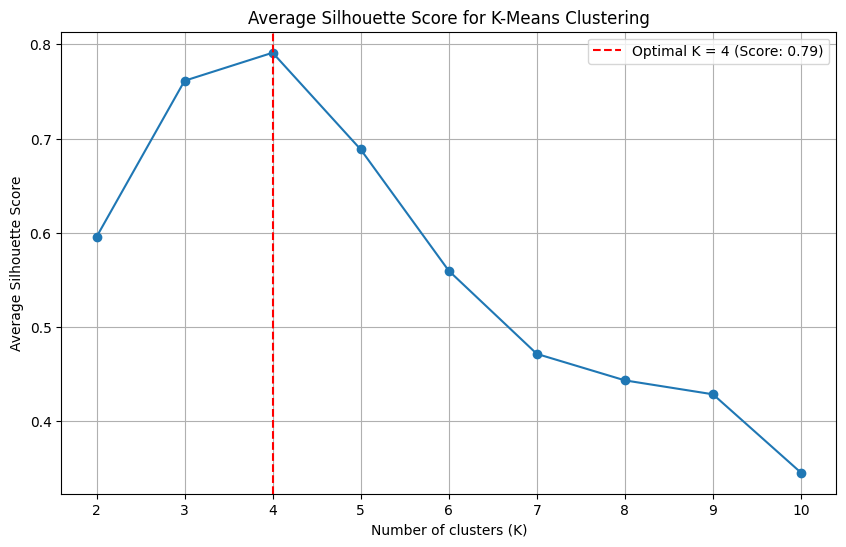

The optimal number of clusters based on the highest Silhouette Score is K = 4 with a score of 0.7911.


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Create a list of K values from 2 to 10
K_values = range(2, 11)

# Plotting the average Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(K_values, silhouette_scores, marker='o', linestyle='-')
plt.title('Average Silhouette Score for K-Means Clustering')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.xticks(K_values)
plt.grid(True)

# Highlight the optimal K (assuming the maximum score indicates optimal K)
optimal_K_index = np.argmax(silhouette_scores)
optimal_K = K_values[optimal_K_index]
optimal_score = silhouette_scores[optimal_K_index]
plt.axvline(x=optimal_K, color='r', linestyle='--', label=f'Optimal K = {optimal_K} (Score: {optimal_score:.2f})')
plt.legend()
plt.show()

print(f"The optimal number of clusters based on the highest Silhouette Score is K = {optimal_K} with a score of {optimal_score:.4f}.")

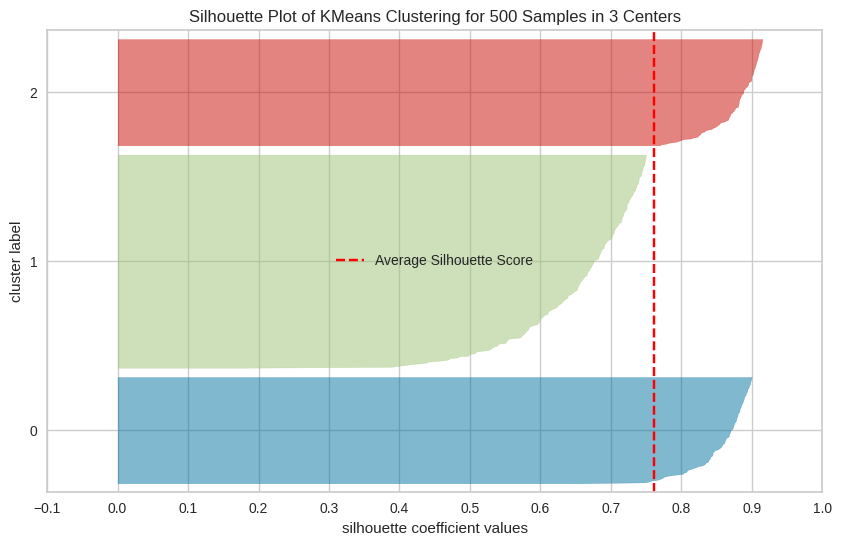

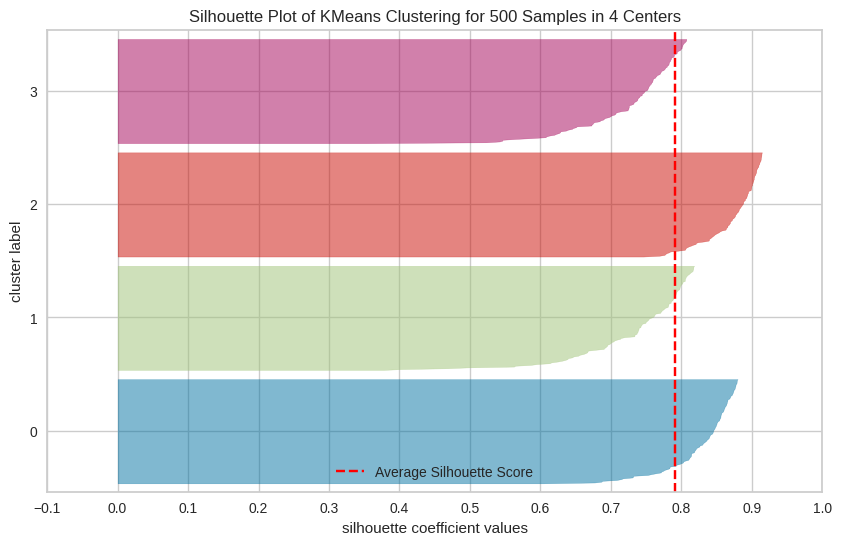

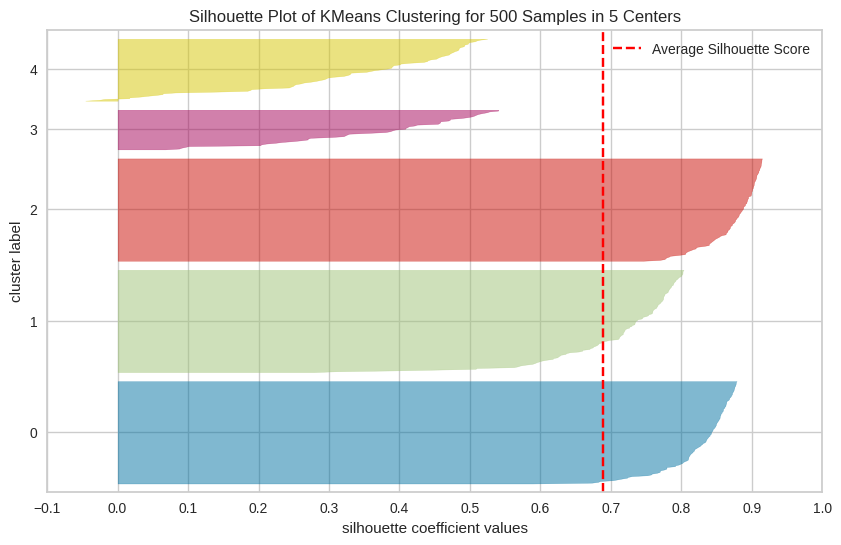

In [5]:
from yellowbrick.cluster import SilhouetteVisualizer

# Visualize Silhouette plots for selected K values
# The optimal K is optimal_K, which is 4
selected_K_values = [3, optimal_K, 5]

for K in selected_K_values:
    # Find the index for the current K value in kmeans_models list
    # K_values starts from 2, so index is K - 2
    model_index = K - 2
    model = kmeans_models[model_index]

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    visualizer = SilhouetteVisualizer(model, colors='yellowbrick', ax=ax)
    visualizer.fit(X) # Fit the visualizer to the data
    visualizer.show() # Finalize and render the figure

## Identify Optimal K

### Subtask:
Based on the average Silhouette scores and the individual Silhouette plots, identify the optimal number of clusters ('K').


### Optimal Number of Clusters (K)

Based on the comprehensive Silhouette analysis, the optimal number of clusters for this synthetic dataset is **K = 4**.

This conclusion is supported by two key observations:

1.  **Average Silhouette Score**: The plot displaying the average Silhouette score for different K values clearly shows a peak at K=4, with a score of **0.7911**. This indicates that, on average, data points are best separated and cohesive within their clusters when grouped into four clusters.
2.  **Individual Silhouette Plots**:
    *   **K=3**: While showing good separation, some clusters in the K=3 plot exhibit slightly less uniform thickness and might contain points that are not as strongly associated with their clusters compared to K=4.
    *   **K=4**: The Silhouette plot for K=4 demonstrates well-defined, relatively thick clusters that extend past the average silhouette score line. Most data points have high silhouette coefficients, indicating strong cohesion within clusters and clear separation from other clusters. There are minimal negative silhouette coefficients, suggesting very few misclassified points.
    *   **K=5**: In contrast, the Silhouette plot for K=5 shows a degradation in clustering quality. Some clusters are thinner, and there are more data points with lower silhouette coefficients, including some dipping below zero. This suggests that adding a fifth cluster forces some points into less natural groupings, leading to reduced separation and cohesion.

Therefore, considering both the quantitative metric and the visual assessment of cluster structure, **K=4** provides the most robust and well-separated clustering solution for the given synthetic data.